In [1]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/monicaromero/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
path_data = '/Users/monicaromero/PycharmProjects/afasia_cat/estudio_datos_notebook/'

df = pd.read_csv(path_data + 'df_transcrip_chunk_info.csv', encoding='utf-8')
df.head()

,Inicio,Fin,Marca,Transcrip_name,Duración,name_chunk_audio,name_chunk_audio_path,CIP,NumId,Gènere,TipusAfàsia,LLengWAB,Edat,Grup,QA,Fluente/No Fluente
0,2.85493,6.58522,perro,02_003_CAT_Lamina,3.73029,02_003_CAT_Lamina_2.85493_6.58522.wav,/Users/monicaromero/PycharmProjects/afasia_cat...,02_003,3,1,1,2,69,1,41.2,No Fluente
1,8.32512,12.09067,IL,02_003_CAT_Lamina,3.76555,02_003_CAT_Lamina_8.32512_12.09067.wav,/Users/monicaromero/PycharmProjects/afasia_cat...,02_003,3,1,1,2,69,1,41.2,No Fluente
2,12.70200,16.44938,IL,02_003_CAT_Lamina,3.74738,02_003_CAT_Lamina_12.70200_16.44938.wav,/Users/monicaromero/PycharmProjects/afasia_cat...,02_003,3,1,1,2,69,1,41.2,No Fluente
3,16.85885,85.00000,IL,02_003_CAT_Lamina,68.14115,02_003_CAT_Lamina_16.85885_85.00000.wav,/Users/monicaromero/PycharmProjects/afasia_cat...,02_003,3,1,1,2,69,1,41.2,No Fluente
4,9.00000,10.23467,arbol,01_001_CAT_descripcio lamina,1.23467,01_001_CAT_descripcio lamina_9.00000_10.23467.wav,/Users/monicaromero/PycharmProjects/afasia_cat...,01_001,1,1,1,1,62,1,44.3,No Fluente


In [4]:
df.columns

Index(['Inicio', 'Fin', 'Marca', 'Transcrip_name', 'Duración',
       'name_chunk_audio', 'name_chunk_audio_path', 'CIP', 'NumId', 'Gènere',
       'TipusAfàsia', 'LLengWAB', 'Edat', 'Grup', 'QA', 'Fluente/No Fluente'],
      dtype='object')

# Nuevas variables

contar_palabras(texto): número total de palabras en la transcripción

palabras_unicas(texto): numero de palabras únicas en la transcripción

promedio_palabras_por_frase(texto): promedio de palabras por transcripción

contar_ininteligibles(texto): numero de veces que aparece "IL" en la transcripción (ininteligibilidad)

palabras_por_minuto(num_palabras, duracion): tasa de palabras por minuto

palabras_por_segundo(num_palabras, duracion): tasa de palabras por segundo

In [5]:
 def contar_palabras(texto):
    """Total number of words in the transcription."""
    return len(texto.split())

def palabras_unicas(texto):
    """Number of unique words in the transcription."""
    return len(set(texto.split()))

def promedio_palabras_por_frase(texto):
    """Average number of words per sentence in the transcription."""
    frases = texto.split('.')  # Split by periods to count sentences
    num_frases = len(frases)
    num_palabras = contar_palabras(texto)
    return num_palabras / num_frases if num_frases > 0 else 0

def contar_ininteligibles(texto):
    """Number of times 'IL' appears in the transcription."""
    return texto.lower().count("il")  # Count how many times "IL" appears

def palabras_por_minuto(num_palabras, duracion):
    """Rate of words per minute."""
    return (num_palabras / duracion) * 60 if duracion > 0 else 0

def palabras_por_segundo(num_palabras, duracion):
    """Rate of words per second."""
    return num_palabras / duracion if duracion > 0 else 0

df['num_palabras'] = df['Marca'].apply(contar_palabras)
df['num_palabras_unicas'] = df['Marca'].apply(palabras_unicas)
df['promedio_palabras_por_frase'] = df['Marca'].apply(promedio_palabras_por_frase)
df['num_ininteligibles'] = df['Marca'].apply(contar_ininteligibles)
df['palabras_por_minuto'] = df.apply(lambda x: palabras_por_minuto(x['num_palabras'], x['Duración']), axis=1)
df['palabras_por_segundo'] = df.apply(lambda x: palabras_por_segundo(x['num_palabras'], x['Duración']), axis=1)
df.head()

,Inicio,Fin,Marca,Transcrip_name,Duración,name_chunk_audio,name_chunk_audio_path,CIP,NumId,Gènere,...,Edat,Grup,QA,Fluente/No Fluente,num_palabras,num_palabras_unicas,promedio_palabras_por_frase,num_ininteligibles,palabras_por_minuto,palabras_por_segundo
0,2.85493,6.58522,perro,02_003_CAT_Lamina,3.73029,02_003_CAT_Lamina_2.85493_6.58522.wav,/Users/monicaromero/PycharmProjects/afasia_cat...,02_003,3,1,...,69,1,41.2,No Fluente,1,1,1.0,0,16.084540,0.268076
1,8.32512,12.09067,IL,02_003_CAT_Lamina,3.76555,02_003_CAT_Lamina_8.32512_12.09067.wav,/Users/monicaromero/PycharmProjects/afasia_cat...,02_003,3,1,...,69,1,41.2,No Fluente,1,1,1.0,1,15.933927,0.265565
2,12.70200,16.44938,IL,02_003_CAT_Lamina,3.74738,02_003_CAT_Lamina_12.70200_16.44938.wav,/Users/monicaromero/PycharmProjects/afasia_cat...,02_003,3,1,...,69,1,41.2,No Fluente,1,1,1.0,1,16.011186,0.266853
3,16.85885,85.00000,IL,02_003_CAT_Lamina,68.14115,02_003_CAT_Lamina_16.85885_85.00000.wav,/Users/monicaromero/PycharmProjects/afasia_cat...,02_003,3,1,...,69,1,41.2,No Fluente,1,1,1.0,1,0.880525,0.014675
4,9.00000,10.23467,arbol,01_001_CAT_descripcio lamina,1.23467,01_001_CAT_descripcio lamina_9.00000_10.23467.wav,/Users/monicaromero/PycharmProjects/afasia_cat...,01_001,1,1,...,62,1,44.3,No Fluente,1,1,1.0,0,48.595981,0.809933


# ANALISIS DEL DATASET

In [6]:
df.describe()

,Inicio,Fin,Duración,NumId,Gènere,TipusAfàsia,LLengWAB,Edat,Grup,QA,num_palabras,num_palabras_unicas,promedio_palabras_por_frase,num_ininteligibles,palabras_por_minuto,palabras_por_segundo
count,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000
mean,111.539406,114.353890,2.814484,5.217311,1.701657,4.248619,1.458564,63.005525,1.405157,60.723020,2.418048,2.366483,2.418048,0.160221,67.454762,1.124246
std,77.787278,77.795052,3.916317,2.092138,0.457953,2.209271,0.498740,10.121857,0.491375,24.749209,2.178435,2.075187,2.178435,0.377066,51.440683,0.857345
min,0.000000,2.328000,1.000470,1.000000,1.000000,1.000000,1.000000,52.000000,1.000000,34.700000,1.000000,1.000000,1.000000,0.000000,0.880525,0.014675
25%,48.255605,51.475095,1.396865,3.000000,1.000000,1.000000,1.000000,53.000000,1.000000,41.800000,1.000000,1.000000,1.000000,0.000000,31.210884,0.520181
50%,95.431510,97.282720,1.958630,5.000000,2.000000,5.000000,1.000000,67.000000,1.000000,44.300000,1.000000,1.000000,1.000000,0.000000,50.033356,0.833889
75%,164.290610,167.834015,2.954040,7.000000,2.000000,6.000000,2.000000,68.000000,2.000000,87.700000,3.000000,3.000000,3.000000,0.000000,97.688574,1.628143
max,314.631510,316.000000,68.141150,8.000000,2.000000,6.000000,2.000000,83.000000,2.000000,96.700000,13.000000,13.000000,13.000000,2.000000,293.106144,4.885102


In [7]:
categorical_columns = ['Marca', 'Transcrip_name', 'Gènere', 'TipusAfàsia', 'Fluente/No Fluente']
for col in categorical_columns:
    print(f"Distribución de valores en '{col}':\n{df[col].value_counts()}\n")

Distribución de valores en 'Marca':
Marca
IL         68
i          19
no          9
bastant     8
un          8
           ..
ve          1
cuide       1
dira        1
algu        1
tu          1
Name: count, Length: 360, dtype: int64

Distribución de valores en 'Transcrip_name':
Transcrip_name
02_007_CAT_Conversacion            118
01_004_CAT__parla_espontania        92
01_003_CAT_Llenguatge_espontani     81
02_007_CAT_Lamina                   65
01_007_CAT_Parla_espontania         49
01_005_CAT_llenguatge_espontani     42
02_008_CAT_Conversacion             37
01_001_CAT_descripcio lamina        30
02_002_CAT_Lamina                   19
02_002_CAT__Conversacion             6
02_003_CAT_Lamina                    4
Name: count, dtype: int64

Distribución de valores en 'Gènere':
Gènere
2    381
1    162
Name: count, dtype: int64

Distribución de valores en 'TipusAfàsia':
TipusAfàsia
6    264
1    168
5    111
Name: count, dtype: int64

Distribución de valores en 'Fluente/No Fluente':
Fl

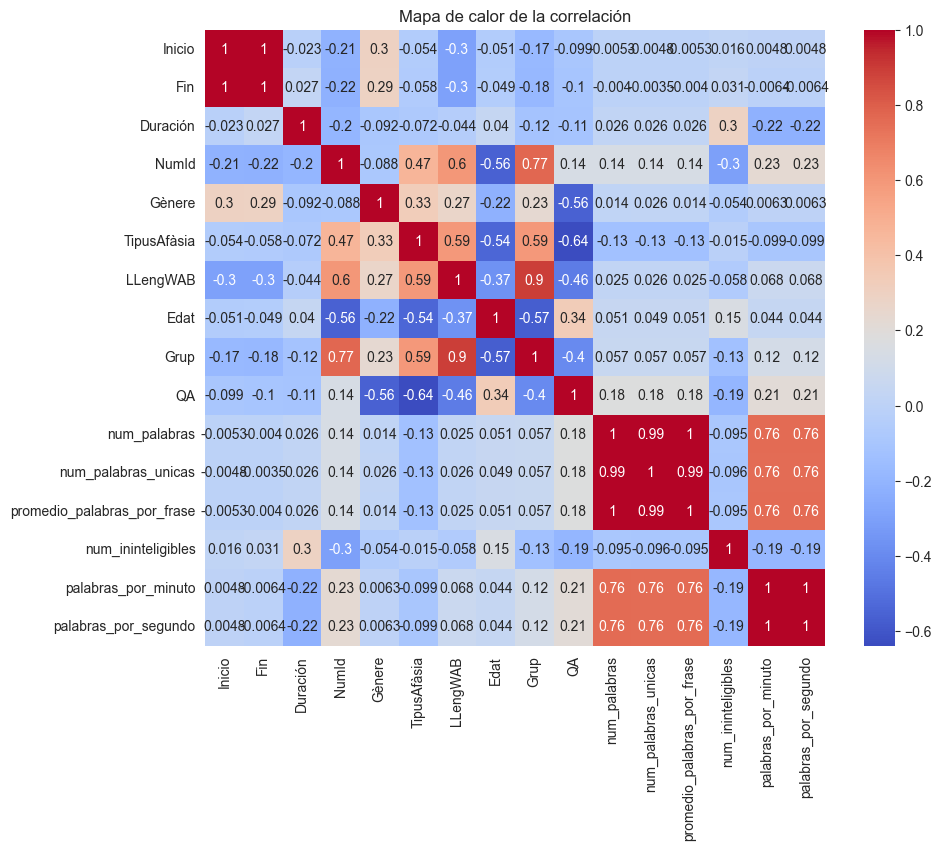

In [8]:
numerical_data = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de calor de la correlación')
plt.show()

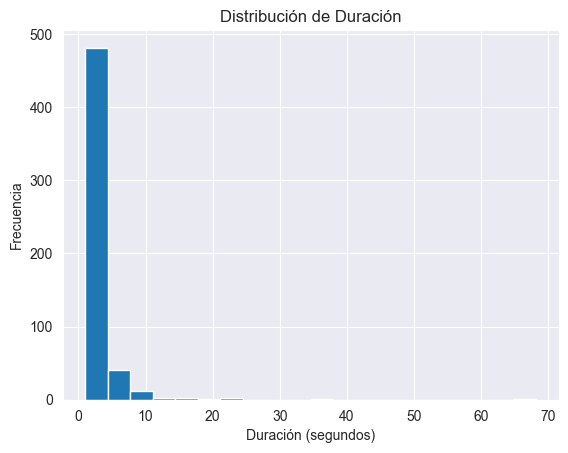

In [9]:
# Histograma de la duración de los audios
plt.hist(df['Duración'], bins=20)
plt.title('Distribución de Duración')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.show()

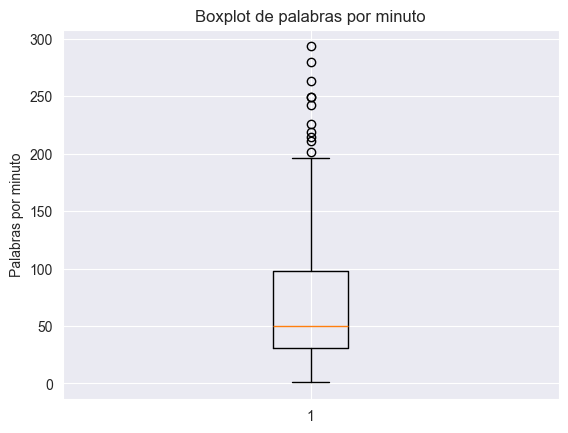

In [10]:
# Boxplot de palabras por minuto
plt.boxplot(df['palabras_por_minuto'])
plt.title('Boxplot de palabras por minuto')
plt.ylabel('Palabras por minuto')
plt.show()

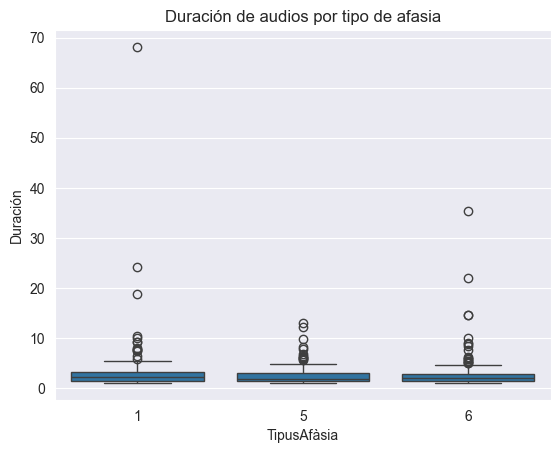

In [11]:
# Comparación de duraciones por tipo de afasia
sns.boxplot(x='TipusAfàsia', y='Duración', data=df)
plt.title('Duración de audios por tipo de afasia')
plt.show()

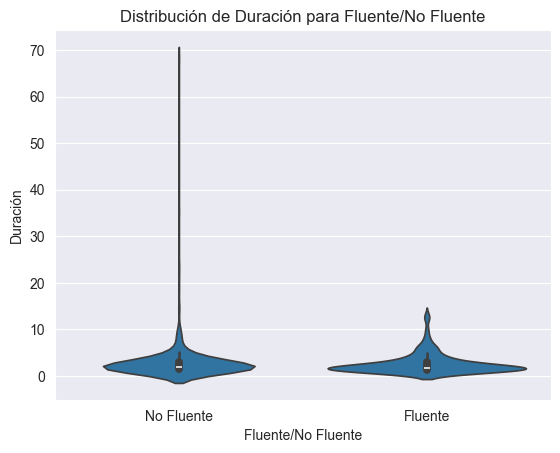

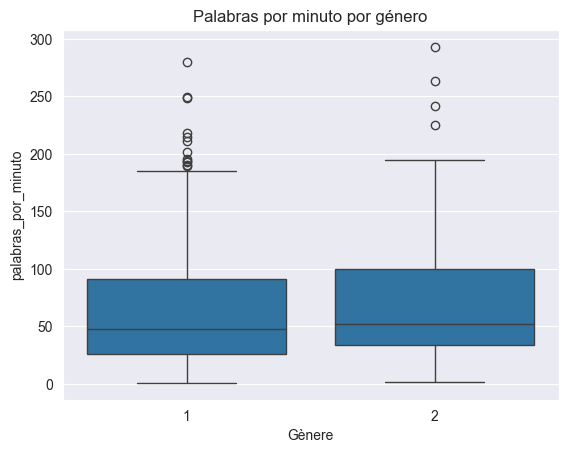

In [12]:
# Comparación entre Fluente/No Fluente y Duración
sns.violinplot(x='Fluente/No Fluente', y='Duración', data=df)
plt.title('Distribución de Duración para Fluente/No Fluente')
plt.show()

# Comparación de género en función de palabras por minuto
sns.boxplot(x='Gènere', y='palabras_por_minuto', data=df)
plt.title('Palabras por minuto por género')
plt.show()

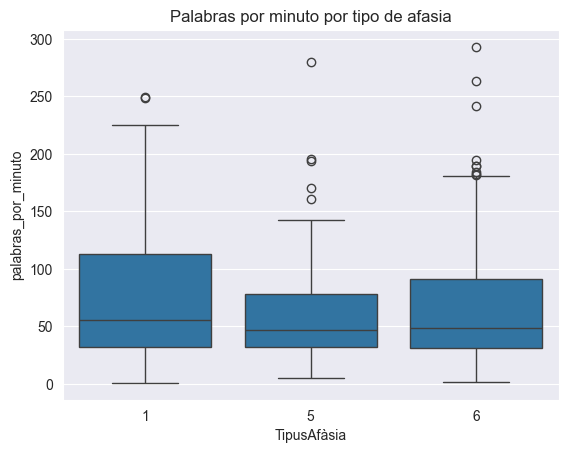

In [13]:
# Comparar palabras por minuto entre tipos de afasia
sns.boxplot(x='TipusAfàsia', y='palabras_por_minuto', data=df)
plt.title('Palabras por minuto por tipo de afasia')
plt.show()

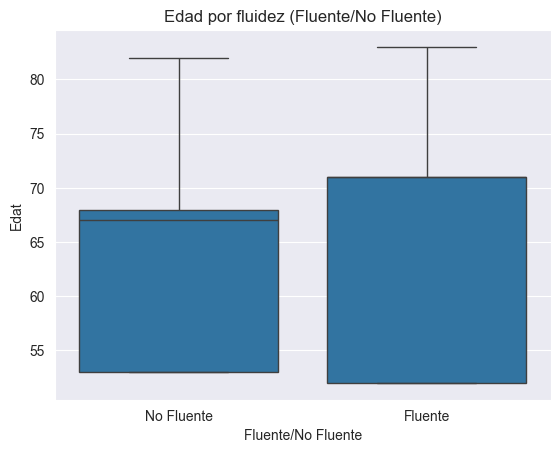

In [14]:
# Comparar la edad según fluidez
sns.boxplot(x='Fluente/No Fluente', y='Edat', data=df)
plt.title('Edad por fluidez (Fluente/No Fluente)')
plt.show()


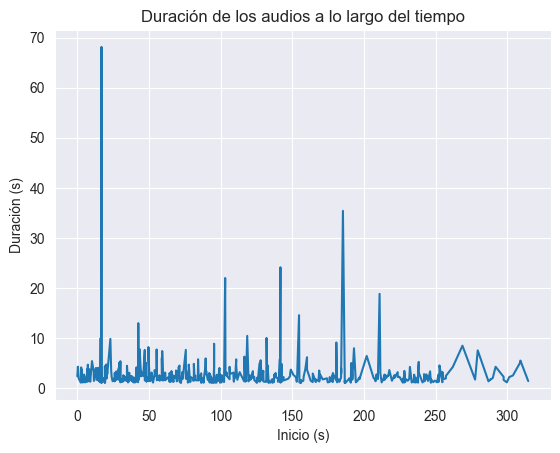

In [15]:
df.sort_values(by='Inicio', inplace=True)
plt.plot(df['Inicio'], df['Duración'])
plt.xlabel('Inicio (s)')
plt.ylabel('Duración (s)')
plt.title('Duración de los audios a lo largo del tiempo')
plt.show()

# NULO

In [16]:
total_transcripciones = len(df)
num_no_fluentes = df['Fluente/No Fluente'].value_counts().get('No Fluente', 0)
num_fluentes = df['Fluente/No Fluente'].value_counts().get('Fluente', 0)

p_nf = num_no_fluentes / total_transcripciones  # prob no fluente
p_f = num_fluentes / total_transcripciones      # prob fluente

# precision teorica del modelo nulo
precision_esperada = p_nf**2 + p_f**2
print(f'precision teorica esperada del modelo nulo: {precision_esperada:.4f}')

# simulacion estocastica del modelo nulo
n_simulaciones = 1000
resultados = []

for _ in range(n_simulaciones):
    # predicciones aleatorias basadas en p_nf y p_f
    predicciones_aleatorias = np.random.choice(['No Fluente', 'Fluente'], size=total_transcripciones, p=[p_nf, p_f])
    
    correctas = (predicciones_aleatorias == df['Fluente/No Fluente']).sum()
    precision_simulada = correctas / total_transcripciones
    resultados.append(precision_simulada)

precision_promedio_simulada = np.mean(resultados)
print(f'precision promedio simulada del modelo nulo: {precision_promedio_simulada:.4f}')

precision teorica esperada del modelo nulo: 0.6747
precision promedio simulada del modelo nulo: 0.6753


In [17]:
conteo_clases = df['Fluente/No Fluente'].value_counts()
clase_mayoritaria = conteo_clases.idxmax()  # identifica clase mayoritaria -> no fluente
num_clase_mayoritaria = conteo_clases.max()  # veces que aparece no fluente , 432
total_transcripciones = len(df) # 543

precision_mayoria = num_clase_mayoritaria / total_transcripciones
print(f'precision esperada del modelo nulo que elige la clase mayoritaria: {precision_mayoria:.4f}')

print(f'clase mayoritaria: {clase_mayoritaria} (se predice siempre esta clase)')

precision esperada del modelo nulo que elige la clase mayoritaria: 0.7956
clase mayoritaria: No Fluente (se predice siempre esta clase)


Superar el 67.4% indica que el modelo es mejor que hacer predicciones al azar.

Superar el 79.56% indica que el modelo es mejor que simplemente predecir "No Fluente" siempre.